# Polynomial regression and overfitting

In this notebook, we explore how model complexity affects performance. In particular, we will:

- Fit polynomial models of different degrees
- Compare training error vs test error
- Observe overfitting

Key idea:
A model that is too complex may fit the training data very well but fail to generalize.

In [32]:
import numpy as np
import matplotlib.pyplot as plt

## Generate synthetic data

- The true function is a sine wave
- We only observe a small number of noisy samples
- This simulates real-world engineering measurements with noise

In [33]:
np.random.seed(0)

N = 8  # small dataset to emphasize overfitting
# Input feature
X = np.linspace(0,2,N).reshape(-1, 1)
# Ground-truth target
y_true = np.sin(2 * np.pi * X[:, 0])
# Noisy observations
y = y_true + 0.2 * np.random.randn(N)

## Goal: recover the underlying relationship from limited data

In [34]:
# Generate dense test data to evaluate the relationship to be learned
X_test = np.linspace(0, 2, 200).reshape(-1, 1)
# Ground-truth target
y_test_true = np.sin(2 * np.pi * X_test[:, 0])

In [35]:
# Function to build polynomial features
# Example: degree=3 → [1, x, x^2, x^3]
def polynomial_design_matrix(X, degree):
    return np.hstack([X**k for k in range(degree + 1)])# Degrees to compare

## Model Complexity

We will compare polynomial models of different degrees:

- Degree 1 → simple (underfitting likely)
- Degree 5 → moderate complexity
- Degree 10 → very flexible (overfitting risk)

Higher degree → more flexibility → higher risk of overfitting.

In [36]:
# Degrees to compare
degrees = [1, 5, 10]

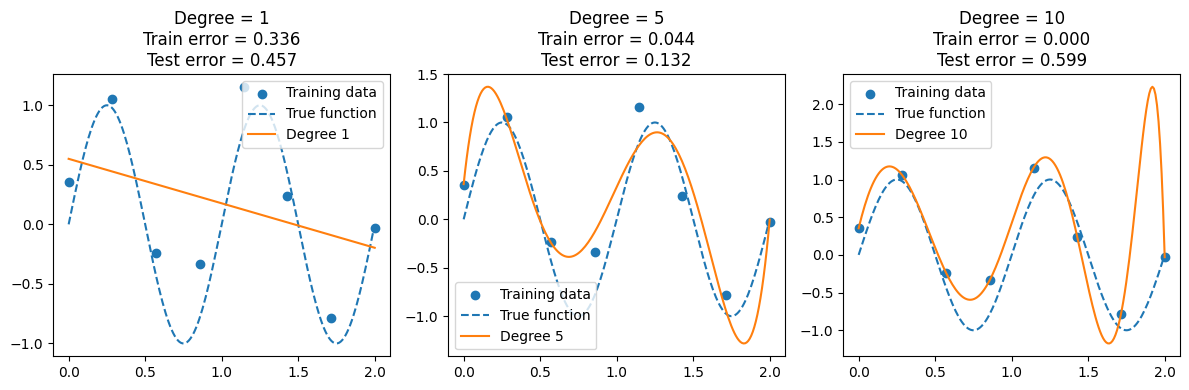

In [37]:
plt.figure(figsize=(12, 4))
for i, deg in enumerate(degrees):
    
    # Evaluate polynomial input features (training and testing data)
    X_train_poly = polynomial_design_matrix(X, deg)
    X_test_poly = polynomial_design_matrix(X_test, deg)
    
    # Fit model on training data (compact call to least squares using available observations)
    beta = np.linalg.pinv(X_train_poly) @ y
    
    # 3. Predictions (evaluate model on both training and testing data)
    y_pred = X_test_poly @ beta
    y_train_pred = X_train_poly @ beta
    
    # Compute training and testing errors (mean squarred error)
    train_error = np.mean((y - y_train_pred)**2)
    test_error = np.mean((y_test_true - y_pred)**2)
    
    # Visualization
    plt.subplot(1, 3, i+1)
    
    plt.scatter(X, y, label="Training data")
    plt.plot(X_test, y_test_true, linestyle="dashed", label="True function")
    plt.plot(X_test, y_pred, label=f"Degree {deg}")
    
    plt.title(
        f"Degree = {deg}\n"
        f"Train error = {train_error:.3f}\n"
        f"Test error = {test_error:.3f}"
    )
    
    plt.legend()
plt.tight_layout()
plt.show()

## Results Interpretation:

#### Degree 1 (Underfitting)
- Too simple to capture the true pattern
- High training error
- High test error

#### Degree 5 (Good fit)
- Captures main structure
- Balanced errors
- Good generalization

#### Degree 10 (Overfitting)
- Fits noise in training data
- Very low training error
- High test error

---

A more complex model is not always better.It is important to ensure the right balance between:
- Bias (too simple)
- Variance (too complex)

Overly complex models ma fit experimental noise and lead to unsafe or unreliable predictions.